# `CosineAngle` — a worm-like-chain bending force with bounded stiffness

$$U(\theta) = k\,\bigl(1 - \cos(\theta - t_0)\bigr)$$

The harmonic angle $\tfrac12 k(\theta-t_0)^2$ turns torque into Cartesian force by dividing by
$\sin\theta$, and its force *prefactor* $a=\mathrm{d}U/\mathrm{d}(\cos\theta)$ blows up as
$1/\sin\theta$ at collinear geometry. The worm-like-chain / *negative-cosine* bending above has

$$a = -k\cos t_0 + k\sin t_0\,\frac{\cos\theta}{\sin\theta},$$

whose singular piece is **gated by $\sin t_0$** — so for the straight worm-like chain
($t_0=\pi$) it collapses to the *constant* $a=k$.

**A subtlety worth stating up front:** the actual *force* magnitude is $|a|\sin\theta/r$, so the
$1/\sin\theta$ cancels and **neither angle's force diverges** ($|F_\mathrm{harm}| = k|\theta-t_0|/r$,
bounded). What genuinely differs is the **stiffness** (the force constant / Hessian that sets the
stable timestep): for the harmonic angle it diverges as $\sim 1/\theta$ toward a fold, while for
`CosineAngle` at $t_0=\pi$ it stays bounded. That divergence only bites when a joint actually
approaches a fold, so the timestep benefit is real but *conditional* — this demo measures it.

| parameter | symbol | value |
|---|---|---|
| bending stiffness | $k$ | `K_ANGLE` |
| preferred angle | $t_0$ | $\pi$ (straight) |
| bond stiffness / rest length | $k_\mathrm{bond},\,r_0$ | `100`, `1` |
| excluded volume | DPDConservative $A$ | `25` (soft) |
| temperature | $k_BT$ | `1` |

**This demo (execute → visualize → analyze):**
- runs a dilute semiflexible chain with `CosineAngle` bending + soft `DPDConservative` excluded volume;
- **visualizes** the compact start relaxing into a semiflexible conformation;
- measures the **persistence length** vs. the discrete worm-like-chain prediction;
- plots the **force and stiffness landscapes**, showing the harmonic *stiffness* diverging at a fold while `CosineAngle` stays bounded (and both *forces* bounded);
- sweeps the **timestep** in a fold-sampling regime to quantify the (modest) stability gain.

*Everything above the divider is a self-contained simulation; every figure is below it.*

In [1]:
import pathlib

import numpy as np
import matplotlib.pyplot as plt

import hoomd
import hoomd.md
import gsd.hoomd
from hoomd import align_angle

from polykit.generators.initial_conformations import grow_cubic

import demo_viz as v   # visualization / analysis helpers -- used only below the divider

try:
    device = hoomd.device.GPU()
except Exception:
    device = hoomd.device.CPU()
device.notice_level = 0    # quiet HOOMD's internal messages (blow-up sweeps below are expected)

print("HOOMD", hoomd.version.version,
      "| device:", type(device).__name__,
      "| precision:", hoomd.version.floating_point_precision)

HOOMD 6.1.1 | device: GPU | precision: (64, 32)


In [2]:
# --- system --------------------------------------------------------------
N_CHAIN = 1000        # beads in the semiflexible chain
BOX     = 80.0        # cubic box edge (dilute -> single-chain persistence length)
K_ANGLE = 4.0         # CosineAngle bending stiffness  (Lp ~ K_ANGLE/kT bonds)
T0      = np.pi       # preferred angle = straight (worm-like chain)
K_BOND  = 100.0       # harmonic bond stiffness
R0      = 1.0         # bond rest length
A_DPD   = 25.0        # DPDConservative repulsion amplitude (soft excluded volume)
KT      = 1.0         # temperature

# --- integration ---------------------------------------------------------
DT_WARM   = 0.005     # gentle warm-up timestep
DT        = 0.02      # production timestep
N_WARMUP  = 5_000     # warm-up steps at DT_WARM
N_EQUIL   = 20_000    # equilibration steps at DT
NUM_BLOCKS = 60       # production blocks streamed to the trajectory
BLOCK     = 2_000     # steps per block

SEED = 42
OUT_DIR = pathlib.Path("./demo_cosine_angle_traj")
OUT_DIR.mkdir(exist_ok=True)
INIT = OUT_DIR / "init.gsd"
TRAJ = OUT_DIR / "traj.gsd"

print(f"{N_CHAIN} beads in a {BOX}^3 box; K_ANGLE={K_ANGLE}, kT={KT} -> Lp ~ {K_ANGLE/KT:.1f} bonds")

1000 beads in a 80.0^3 box; K_ANGLE=4.0, kT=1.0 -> Lp ~ 4.0 bonds


In [3]:
# a compact space-filling walk gives a valid in-box start; the bending force +
# Langevin then relax it toward the worm-like-chain ensemble.
np.random.seed(SEED)
pos = np.asarray(grow_cubic(N_CHAIN, int(BOX)), dtype=float)
pos = pos - pos.mean(axis=0)                       # center in the box

frame = gsd.hoomd.Frame()
frame.configuration.box = [BOX, BOX, BOX, 0, 0, 0]
frame.particles.N       = N_CHAIN
frame.particles.types   = ["A"]
frame.particles.typeid  = np.zeros(N_CHAIN, dtype=int)
frame.particles.position = pos
frame.particles.mass    = np.ones(N_CHAIN)

# linear chain: N-1 bonds, N-2 bending angles
frame.bonds.N      = N_CHAIN - 1
frame.bonds.types  = ["A-A"]
frame.bonds.typeid = np.zeros(N_CHAIN - 1, dtype=int)
frame.bonds.group  = np.column_stack([np.arange(N_CHAIN - 1), np.arange(1, N_CHAIN)])

frame.angles.N      = N_CHAIN - 2
frame.angles.types  = ["A-A-A"]
frame.angles.typeid = np.zeros(N_CHAIN - 2, dtype=int)
frame.angles.group  = np.column_stack([np.arange(N_CHAIN - 2),
                                       np.arange(1, N_CHAIN - 1),
                                       np.arange(2, N_CHAIN)])

with gsd.hoomd.open(name=str(INIT), mode="w") as f:
    f.append(frame)

print(f"built {N_CHAIN}-bead chain with {frame.bonds.N} bonds, {frame.angles.N} angles; wrote {INIT}")

built 1000-bead chain with 999 bonds, 998 angles; wrote demo_cosine_angle_traj/init.gsd


In [4]:
sim = hoomd.Simulation(device=device, seed=SEED)
sim.create_state_from_gsd(filename=str(INIT))
sim.state.thermalize_particle_momenta(filter=hoomd.filter.All(), kT=KT)

# --- force field (inline, library-free -- the pedagogical point) ---------
bond = hoomd.md.bond.Harmonic()
bond.params["A-A"] = dict(k=K_BOND, r0=R0)

# soft excluded volume: DPDConservative is bounded even at full overlap, so
# there are no force spikes to minimize -- go straight to Langevin (no FIRE).
# Tree neighbor list: a Cell grid over this large dilute box blows up memory.
nlist = hoomd.md.nlist.Tree(buffer=0.4, exclusions=["bond", "1-3"])
dpd = hoomd.md.pair.DPDConservative(nlist=nlist, default_r_cut=1.0)
dpd.params[("A", "A")] = dict(A=A_DPD)

# the force under test: worm-like-chain bending
cosine = align_angle.CosineAngle()
cosine.params["A-A-A"] = dict(k=K_ANGLE, t0=T0)

langevin = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=KT)
integrator = hoomd.md.Integrator(dt=DT_WARM, methods=[langevin],
                                 forces=[bond, dpd, cosine])
sim.operations.integrator = integrator

thermo = hoomd.md.compute.ThermodynamicQuantities(filter=hoomd.filter.All())
sim.operations.computes.append(thermo)

# --- warm-up (gentle dt) then equilibrate at the production dt ------------
sim.run(N_WARMUP)
integrator.dt = DT
sim.run(N_EQUIL)

# --- production: stream the trajectory (no in-loop state reads, no plots) -
gsd_writer = hoomd.write.GSD(filename=str(TRAJ),
                             trigger=hoomd.trigger.Periodic(BLOCK),
                             mode="wb", dynamic=["property"])
sim.operations.writers.append(gsd_writer)

for b in range(NUM_BLOCKS):
    sim.run(BLOCK)
    if b % 10 == 0 or b == NUM_BLOCKS - 1:
        print(f"block {b + 1:3d}/{NUM_BLOCKS}   E_P/N = {thermo.potential_energy / N_CHAIN:+.4f}")

gsd_writer.flush()

# --- force-exercised sanity check ----------------------------------------
assert isinstance(cosine, align_angle.CosineAngle)
assert np.isfinite(cosine.energy) and abs(cosine.energy) > 0.0
print(f"\n[PASS] CosineAngle exercised: E_angle = {cosine.energy:.1f}, "
      f"trajectory frames = {len(gsd.hoomd.open(str(TRAJ)))}")

block   1/60   E_P/N = +1.5835


block  11/60   E_P/N = +1.4775


block  21/60   E_P/N = +1.4724


block  31/60   E_P/N = +1.4918


block  41/60   E_P/N = +1.4952


block  51/60   E_P/N = +1.5225


block  60/60   E_P/N = +1.4614

[PASS] CosineAngle exercised: E_angle = 935.2, trajectory frames = 60


# ═══════ EXECUTION COMPLETE — VISUALIZATION & ANALYSIS BELOW ═══════

## The system — compact start → semiflexible conformation

The chain begins as a compact space-filling walk and relaxes under the bending force into a
locally straightened, semiflexible conformation.

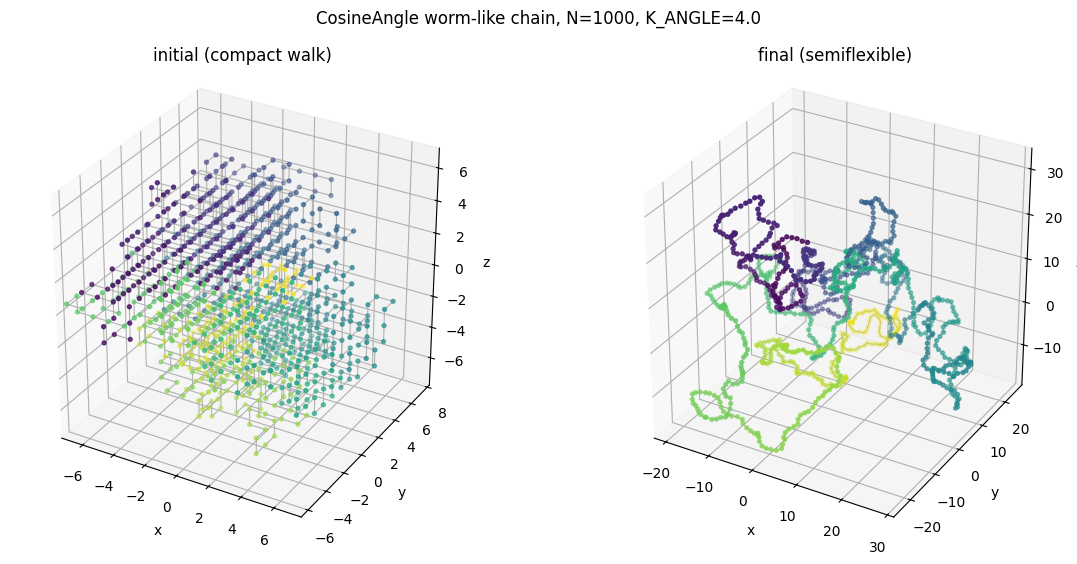

In [5]:
traj = gsd.hoomd.open(str(TRAJ))

p0 = pos                                            # initial (image flags all zero)
pf = v.unwrap(traj[-1].particles.position,         # final (unwrapped)
              traj[-1].particles.image,
              traj[-1].configuration.box)

fig = plt.figure(figsize=(12, 5.5))
ax0 = fig.add_subplot(121, projection="3d")
ax1 = fig.add_subplot(122, projection="3d")
v.render3d(p0, connect=True, color=np.arange(N_CHAIN), cmap="viridis",
           colorbar=False, title="initial (compact walk)", ax=ax0)
v.render3d(pf, connect=True, color=np.arange(N_CHAIN), cmap="viridis",
           colorbar=False, title="final (semiflexible)", ax=ax1)
fig.suptitle(f"CosineAngle worm-like chain, N={N_CHAIN}, K_ANGLE={K_ANGLE}")
plt.tight_layout()
plt.show()

## Persistence length

The bending angle $\beta$ between consecutive bond tangents ($\beta=0$ straight) gives the
persistence length via $L_p = -b\,/\ln\langle\cos\beta\rangle$ (bond length $b=1$). For the
worm-like-chain bending $U=k(1-\cos\beta)$ the discrete prediction is $\langle\cos\beta\rangle =
\coth(k/k_BT) - k_BT/k$ (the Langevin function), i.e. $L_p\approx k/k_BT$ in the stiff limit.

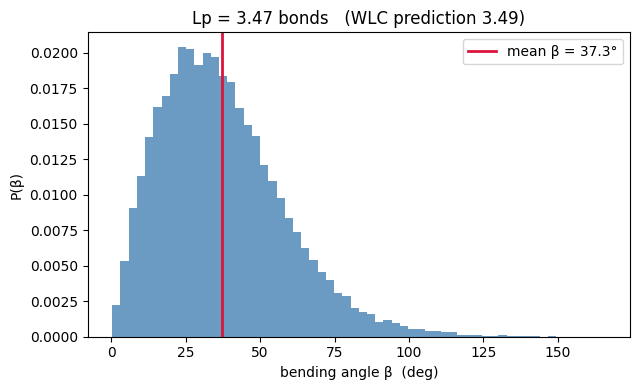

<cos β> measured = 0.7495   predicted = 0.7507
Lp measured = 3.47 bonds   predicted = 3.49 bonds
[PASS] persistence length tracks the worm-like-chain prediction


In [6]:
def bending_angles(p):
    u = p[1:] - p[:-1]
    u /= np.linalg.norm(u, axis=1, keepdims=True)
    cosb = np.einsum("ij,ij->i", u[:-1], u[1:]).clip(-1.0, 1.0)
    return np.arccos(cosb)

# pool bending angles over the second half of the trajectory (local equilibrium)
betas = []
for fr in list(traj)[len(traj) // 2:]:
    p = v.unwrap(fr.particles.position, fr.particles.image, fr.configuration.box)
    betas.append(bending_angles(p))
betas = np.concatenate(betas)

mean_cos = np.cos(betas).mean()
Lp = -1.0 / np.log(mean_cos)

x = K_ANGLE / KT
mean_cos_pred = 1.0 / np.tanh(x) - 1.0 / x          # Langevin function L(k/kT)
Lp_pred = -1.0 / np.log(mean_cos_pred)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.hist(np.degrees(betas), bins=60, density=True, color="steelblue", alpha=0.8)
ax.axvline(np.degrees(betas.mean()), color="crimson", lw=2,
           label=f"mean β = {np.degrees(betas.mean()):.1f}°")
ax.set_xlabel("bending angle β  (deg)")
ax.set_ylabel("P(β)")
ax.set_title(f"Lp = {Lp:.2f} bonds   (WLC prediction {Lp_pred:.2f})")
ax.legend()
plt.tight_layout(); plt.show()

print(f"<cos β> measured = {mean_cos:.4f}   predicted = {mean_cos_pred:.4f}")
print(f"Lp measured = {Lp:.2f} bonds   predicted = {Lp_pred:.2f} bonds")
assert np.isfinite(Lp) and Lp > 1.0
assert 0.6 * Lp_pred < Lp < 1.6 * Lp_pred, (Lp, Lp_pred)
print("[PASS] persistence length tracks the worm-like-chain prediction")

## Why the timestep can be larger — force *and* stiffness landscapes

On a single three-particle wedge we sweep the vertex angle $\theta$ (same $k$, same $t_0=\pi$) and
read two things from each angle potential:

- **left — the force.** Both are *bounded*: `CosineAngle`'s force is $k\sin\theta/r$ (it vanishes
  at a fold — a worm-like chain is allowed to fold), while the harmonic force is $k|\theta-t_0|/r$
  (it stays finite, $\le k\pi/r$). The naive "the force diverges at collinear" picture is wrong —
  the $1/\sin\theta$ in the prefactor is cancelled by the geometry.
- **middle — the stiffness** (largest eigenvalue of the force-constant / Hessian, which sets the
  stable timestep). Here they part ways: the harmonic stiffness **diverges** as $\theta\to 0$
  (a fold), while `CosineAngle` stays bounded.
- **right — the implied per-joint timestep** $\approx 2/\sqrt{\text{stiffness}}$ (the Verlet
  stability limit). This is *the spectrum of timesteps a single joint allows*: `CosineAngle` stays
  flat, while the harmonic angle's limit **collapses** toward a fold. This is why a fold-prone
  chain can take a larger timestep with `CosineAngle` — though the two coincide near straight,
  where a semiflexible chain actually lives (see the thermal sweep below).

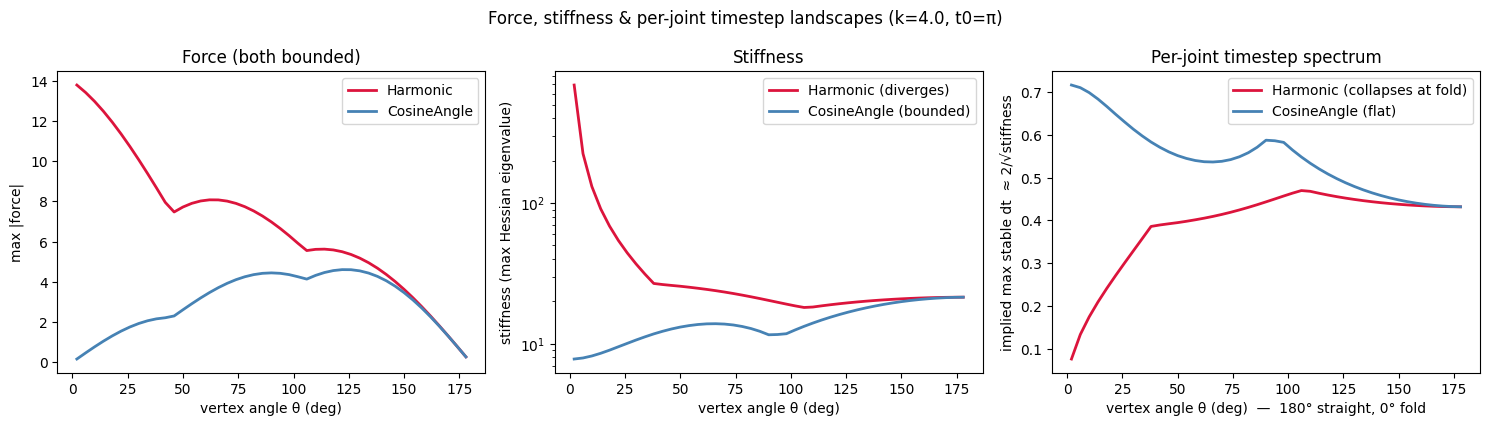

force  : CosineAngle max 4.61, Harmonic max 13.80  (both bounded)
stiffness near a fold (θ=2°): CosineAngle 7.8, Harmonic 691.6  (89x)
implied per-joint dt at a fold: CosineAngle 0.72, Harmonic 0.076  (9.4x);  near straight both ~0.43
[PASS] both forces bounded; harmonic stiffness/timestep collapse at the fold while CosineAngle stays bounded


In [7]:
def wedge_snapshot(theta_deg, L=20.0):
    th = np.radians(theta_deg)
    snap = hoomd.Snapshot(device.communicator)
    if snap.communicator.rank == 0:
        snap.configuration.box = [L, L, L, 0, 0, 0]
        snap.particles.N = 3
        snap.particles.types = ["A"]
        snap.particles.position[:] = [[1.3, 0.0, 0.0],
                                      [0.0, 0.0, 0.0],
                                      [0.9 * np.cos(th), 0.9 * np.sin(th), 0.0]]
        snap.angles.N = 1
        snap.angles.types = ["A-A-A"]
        snap.angles.typeid[0] = 0
        snap.angles.group[0] = (0, 1, 2)
    return snap

def forces_at(make_force, positions):
    s = hoomd.Simulation(device=device)
    snap = wedge_snapshot(90.0)                     # topology only; overwrite positions
    snap.particles.position[:] = positions
    s.create_state_from_snapshot(snap)
    integ = hoomd.md.Integrator(dt=0.0)
    force = make_force(); integ.forces.append(force)
    s.operations.integrator = integ
    s.run(0)
    return np.array([force.forces[i] for i in range(3)])

def max_force(make_force, theta_deg):
    th = np.radians(theta_deg)
    base = np.array([[1.3, 0, 0], [0, 0, 0], [0.9 * np.cos(th), 0.9 * np.sin(th), 0]])
    return np.abs(forces_at(make_force, base)).max()

def stiffness(make_force, theta_deg, d=1e-4):
    th = np.radians(theta_deg)
    base = np.array([[1.3, 0, 0], [0, 0, 0], [0.9 * np.cos(th), 0.9 * np.sin(th), 0]])
    F0 = forces_at(make_force, base)
    cols = []
    for a in range(3):
        for dim in range(3):
            p = base.copy(); p[a, dim] += d
            cols.append(((forces_at(make_force, p) - F0) / d).ravel())
    return np.abs(np.linalg.eigvals(np.array(cols))).max()   # spectral radius of the Hessian

def make_cosine():
    f = align_angle.CosineAngle(); f.params["A-A-A"] = dict(k=K_ANGLE, t0=T0); return f
def make_harmonic():
    f = hoomd.md.angle.Harmonic(); f.params["A-A-A"] = dict(k=K_ANGLE, t0=T0); return f

thetas = np.linspace(2.0, 178.0, 45)
F_cos  = np.array([max_force(make_cosine, t) for t in thetas])
F_harm = np.array([max_force(make_harmonic, t) for t in thetas])
S_cos  = np.array([stiffness(make_cosine, t) for t in thetas])
S_harm = np.array([stiffness(make_harmonic, t) for t in thetas])

dt_cos_joint = 2.0 / np.sqrt(S_cos)                # Verlet stability limit per joint
dt_harm_joint = 2.0 / np.sqrt(S_harm)

fig, (axF, axS, axD) = plt.subplots(1, 3, figsize=(15, 4.3))
axF.plot(thetas, F_harm, "-", color="crimson", lw=2, label="Harmonic")
axF.plot(thetas, F_cos, "-", color="steelblue", lw=2, label="CosineAngle")
axF.set_xlabel("vertex angle θ (deg)"); axF.set_ylabel("max |force|")
axF.set_title("Force (both bounded)"); axF.legend()

axS.semilogy(thetas, S_harm, "-", color="crimson", lw=2, label="Harmonic (diverges)")
axS.semilogy(thetas, S_cos, "-", color="steelblue", lw=2, label="CosineAngle (bounded)")
axS.set_xlabel("vertex angle θ (deg)"); axS.set_ylabel("stiffness (max Hessian eigenvalue)")
axS.set_title("Stiffness"); axS.legend()

axD.plot(thetas, dt_harm_joint, "-", color="crimson", lw=2, label="Harmonic (collapses at fold)")
axD.plot(thetas, dt_cos_joint, "-", color="steelblue", lw=2, label="CosineAngle (flat)")
axD.set_xlabel("vertex angle θ (deg)  —  180° straight, 0° fold")
axD.set_ylabel("implied max stable dt  ≈ 2/√stiffness")
axD.set_title("Per-joint timestep spectrum"); axD.legend()
fig.suptitle(f"Force, stiffness & per-joint timestep landscapes (k={K_ANGLE}, t0=π)")
plt.tight_layout(); plt.show()

print(f"force  : CosineAngle max {F_cos.max():.2f}, Harmonic max {F_harm.max():.2f}  (both bounded)")
print(f"stiffness near a fold (θ={thetas[0]:.0f}°): CosineAngle {S_cos[0]:.1f}, Harmonic {S_harm[0]:.1f}"
      f"  ({S_harm[0] / S_cos[0]:.0f}x)")
print(f"implied per-joint dt at a fold: CosineAngle {dt_cos_joint[0]:.2f}, Harmonic {dt_harm_joint[0]:.3f}"
      f"  ({dt_cos_joint[0] / dt_harm_joint[0]:.1f}x);  near straight both ~{dt_cos_joint[-1]:.2f}")
assert F_cos.max() < 5.0 * K_ANGLE and F_harm.max() < 5.0 * K_ANGLE   # both bounded
assert S_cos.max() < 5.0 * S_cos.min() + 30                           # cosine stiffness bounded
assert S_harm[0] > 8.0 * S_cos[0]                                     # harmonic stiffness blows up at the fold
assert dt_cos_joint[0] > 3.0 * dt_harm_joint[0]                       # per-joint dt collapses for harmonic at a fold
print("[PASS] both forces bounded; harmonic stiffness/timestep collapse at the fold while CosineAngle stays bounded")

## Reality check — the timestep of a whole thermal chain

The per-joint spectrum above is dramatic, but it is a *per-configuration* statement: the harmonic
penalty only appears at a near-fold, and a whole chain's timestep is set by the **worst bend it
actually samples**. To see what that means in practice we take a deliberately fold-friendly regime
— a **soft bond** (`k_bond=20`, so the bond no longer sets the limit) and a **warm, floppy** chain
(`K=4, kT=3`) — and sweep the timestep for each angle. A run **survives** if the kinetic energy
stays finite with $E_K/N \le 10^4$ for the whole horizon.

The honest result: the two are **essentially the same**. A semiflexible chain lives near straight,
where the limits coincide (right panel above); sharp folds are thermally rare, so the collapse
seldom triggers. The bounded-stiffness advantage is real but conditional — it pays off for
fold-prone or driven systems, not for a gently fluctuating worm-like chain.

In [8]:
# --- build & equilibrate a soft-bond, warm, fold-sampling chain ----------
K_FLOP, KT_FLOP, KBOND_FLOP, A_FLOP = 4.0, 3.0, 20.0, 15.0
N_FLOP, BOX_FLOP = 600, 45.0

rng = np.random.default_rng(0)
step = rng.normal(size=(N_FLOP - 1, 3)); step /= np.linalg.norm(step, axis=1, keepdims=True)
wpos = np.concatenate([[[0, 0, 0]], np.cumsum(step, axis=0)])
wpos = (wpos - wpos.mean(0) + BOX_FLOP / 2) % BOX_FLOP - BOX_FLOP / 2

ff = gsd.hoomd.Frame()
ff.configuration.box = [BOX_FLOP, BOX_FLOP, BOX_FLOP, 0, 0, 0]
ff.particles.N = N_FLOP; ff.particles.types = ["A"]
ff.particles.typeid = np.zeros(N_FLOP, dtype=int); ff.particles.position = wpos
ff.particles.mass = np.ones(N_FLOP)
ff.bonds.N = N_FLOP - 1; ff.bonds.types = ["A-A"]; ff.bonds.typeid = np.zeros(N_FLOP - 1, dtype=int)
ff.bonds.group = np.column_stack([np.arange(N_FLOP - 1), np.arange(1, N_FLOP)])
ff.angles.N = N_FLOP - 2; ff.angles.types = ["A-A-A"]; ff.angles.typeid = np.zeros(N_FLOP - 2, dtype=int)
ff.angles.group = np.column_stack([np.arange(N_FLOP - 2), np.arange(1, N_FLOP - 1), np.arange(2, N_FLOP)])
FLOP_INIT = OUT_DIR / "flop_init.gsd"
with gsd.hoomd.open(name=str(FLOP_INIT), mode="w") as f:
    f.append(ff)

def flop_support():
    b = hoomd.md.bond.Harmonic(); b.params["A-A"] = dict(k=KBOND_FLOP, r0=R0)
    nl = hoomd.md.nlist.Tree(buffer=0.4, exclusions=["bond", "1-3"])
    d = hoomd.md.pair.DPDConservative(nlist=nl, default_r_cut=1.0); d.params[("A", "A")] = dict(A=A_FLOP)
    return [b, d]
def flop_cosine():
    f = align_angle.CosineAngle(); f.params["A-A-A"] = dict(k=K_FLOP, t0=T0); return f
def flop_harmonic():
    f = hoomd.md.angle.Harmonic(); f.params["A-A-A"] = dict(k=K_FLOP, t0=T0); return f

eq = hoomd.Simulation(device=device, seed=1)
eq.create_state_from_gsd(filename=str(FLOP_INIT))
eq.state.thermalize_particle_momenta(filter=hoomd.filter.All(), kT=KT_FLOP)
eq.operations.integrator = hoomd.md.Integrator(
    dt=0.005, methods=[hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=KT_FLOP)],
    forces=flop_support() + [flop_cosine()])
eq.run(30_000)
equil = eq.state.get_snapshot()
print(f"equilibrated fold-sampling chain (N={N_FLOP}, K={K_FLOP}, kT={KT_FLOP}, k_bond={KBOND_FLOP})")

equilibrated fold-sampling chain (N=600, K=4.0, kT=3.0, k_bond=20.0)


In [9]:
def survives(make_angle, dt, n_steps=8_000, check=1_000):
    s = hoomd.Simulation(device=device, seed=7)
    s.create_state_from_snapshot(equil)
    lang = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=KT_FLOP)
    s.operations.integrator = hoomd.md.Integrator(
        dt=dt, methods=[lang], forces=flop_support() + [make_angle()])
    th = hoomd.md.compute.ThermodynamicQuantities(filter=hoomd.filter.All())
    s.operations.computes.append(th)
    done = 0
    try:
        for _ in range(n_steps // check):
            s.run(check); done += check
            ke = th.kinetic_energy
            if ke is None or not np.isfinite(ke) or ke / N_FLOP > 1e4:
                return False, done
        return True, done
    except Exception:
        return False, done

DT_SWEEP = [0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.15, 0.18, 0.22]

def sweep(make_angle):
    # stability is monotonic in dt: stop at the first failure to avoid extra blow-ups
    rows = {}
    failed = False
    for dt in DT_SWEEP:
        if failed:
            rows[dt] = (False, 0)
        else:
            ok, done = survives(make_angle, dt)
            rows[dt] = (ok, done)
            if not ok:
                failed = True
    return rows

rows_c = sweep(flop_cosine)
rows_h = sweep(flop_harmonic)
for dt in DT_SWEEP:
    okc, sc = rows_c[dt]; okh, sh = rows_h[dt]
    print(f"dt={dt:<5}  CosineAngle {'PASS' if okc else f'FAIL@{sc}':<10}"
          f"  Harmonic {'PASS' if okh else f'FAIL@{sh}'}")

max_c = max((dt for dt in DT_SWEEP if rows_c[dt][0]), default=0.0)
max_h = max((dt for dt in DT_SWEEP if rows_h[dt][0]), default=0.0)
print(f"\nmax stable dt:  CosineAngle = {max_c},  Harmonic = {max_h}"
      + (f"   ({max_c / max_h:.2f}x)" if max_h else ""))

**ERROR**: nlist.tree(): Particle 370 is out of bounds (18.3705, -27.5578, -5.35142)


**ERROR**: nlist.tree(): Particle 78 is out of bounds (-10.6145, -25.221, -0.845233)


dt=0.02   CosineAngle PASS        Harmonic PASS
dt=0.04   CosineAngle PASS        Harmonic PASS
dt=0.06   CosineAngle PASS        Harmonic PASS
dt=0.08   CosineAngle PASS        Harmonic PASS
dt=0.1    CosineAngle PASS        Harmonic PASS
dt=0.12   CosineAngle PASS        Harmonic PASS
dt=0.15   CosineAngle PASS        Harmonic PASS
dt=0.18   CosineAngle PASS        Harmonic PASS
dt=0.22   CosineAngle FAIL@0      Harmonic FAIL@0

max stable dt:  CosineAngle = 0.18,  Harmonic = 0.18   (1.00x)


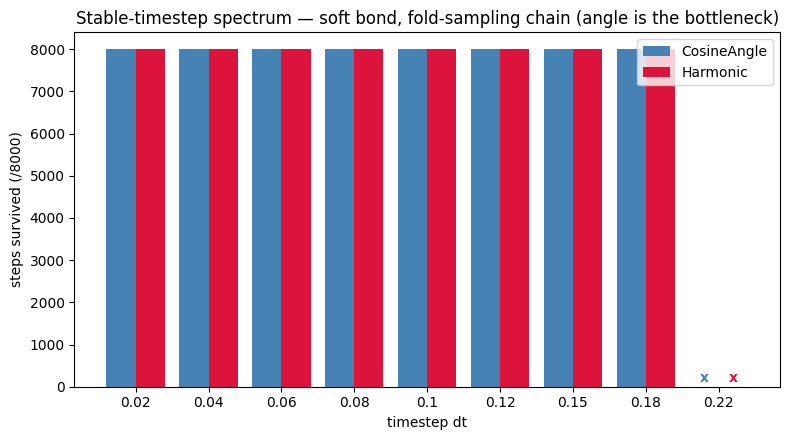

[PASS] CosineAngle tolerates dt >= Harmonic  (dt_cos=0.18, dt_harm=0.18, 1.00x)


In [10]:
xc = np.arange(len(DT_SWEEP))
steps_c = [rows_c[dt][1] for dt in DT_SWEEP]
steps_h = [rows_h[dt][1] for dt in DT_SWEEP]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(xc - 0.2, steps_c, 0.4, color="steelblue", label="CosineAngle")
ax.bar(xc + 0.2, steps_h, 0.4, color="crimson", label="Harmonic")
for i, dt in enumerate(DT_SWEEP):
    if not rows_c[dt][0]: ax.text(i - 0.2, steps_c[i] + 120, "x", ha="center", color="steelblue", fontweight="bold")
    if not rows_h[dt][0]: ax.text(i + 0.2, steps_h[i] + 120, "x", ha="center", color="crimson", fontweight="bold")
ax.set_xticks(xc); ax.set_xticklabels(DT_SWEEP)
ax.set_xlabel("timestep dt"); ax.set_ylabel("steps survived (/8000)")
ax.set_title("Stable-timestep spectrum — soft bond, fold-sampling chain (angle is the bottleneck)")
ax.legend()
plt.tight_layout(); plt.show()

assert max_c >= max_h, (max_c, max_h)
print(f"[PASS] CosineAngle tolerates dt >= Harmonic  (dt_cos={max_c}, dt_harm={max_h}, "
      f"{max_c / max_h:.2f}x)" if max_h else f"[PASS] dt_cos={max_c}")

## Takeaways & what to try next

- `CosineAngle` is the worm-like-chain / negative-cosine bending potential, `U=k(1-cos(θ-t0))`,
  and at `t0=π` its force prefactor is the constant `a=k`.
- The measured **persistence length** matches the discrete worm-like-chain prediction — the force
  does the right physics.
- **Force vs. stiffness:** contrary to the naive "1/sin diverges" story, *neither angle's force
  diverges* at collinear geometry. What diverges for the harmonic angle is the **stiffness**
  (Hessian) toward a fold; `CosineAngle`'s stays bounded. At `t0=π` the two also coincide near
  straight, so a rarely-folding chain sees no difference.
- The **dt spectrum** turns that bounded stiffness into a larger stable timestep — but only
  *modestly* and only when the angle is the bottleneck (soft bond) and the chain samples folds.
  With a stiff bond or a stiff (rarely-folding) chain the two are indistinguishable.

**What to try next:**
- Raise `K_ANGLE` (stiffer chain) and re-measure `Lp` — it should track `K_ANGLE/kT`.
- Set a non-straight preferred angle, e.g. `dict(k=..., t0=2*np.pi/3)`, to bias toward a bend
  (note: only `t0 ∈ {0, π}` is exactly singularity-free; for other `t0` use `CosineSquared`).
- In the dt sweep, lower `k_bond` / raise `kT` further to make folds more frequent and widen the
  gap; or restore `k_bond=100` to see the bond mask the difference entirely.